In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv(
    "../data/processed/task2_sentiment_analysis.csv"
)

df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,identified_theme
0,Good,5,2026-05-16,CBE,Google Play,positive,0.4404,Other
1,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play,neutral,0.0000,Other
2,worst,1,2026-05-16,CBE,Google Play,negative,-0.6249,Other
3,this app very full,5,2026-05-16,CBE,Google Play,neutral,0.0000,Other
4,good apps,4,2026-05-16,CBE,Google Play,positive,0.4404,Other


In [2]:
print(df.columns)

print(df.shape)

print(df['bank'].value_counts())

Index(['review', 'rating', 'date', 'bank', 'source', 'sentiment_label',
       'sentiment_score', 'identified_theme'],
      dtype='str')
(1500, 8)
bank
CBE       500
BOA       500
Dashen    500
Name: count, dtype: int64


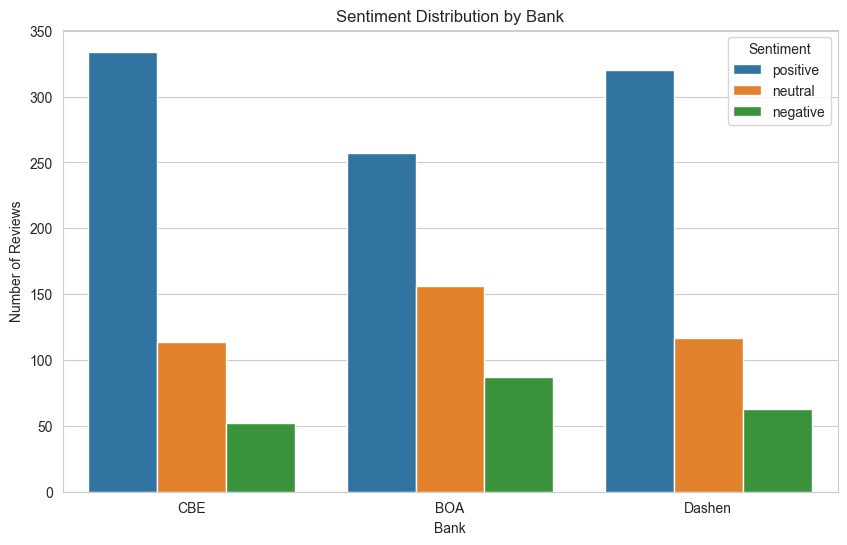

In [3]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='bank',
    hue='sentiment_label'
)

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

plt.legend(title="Sentiment")

plt.show()

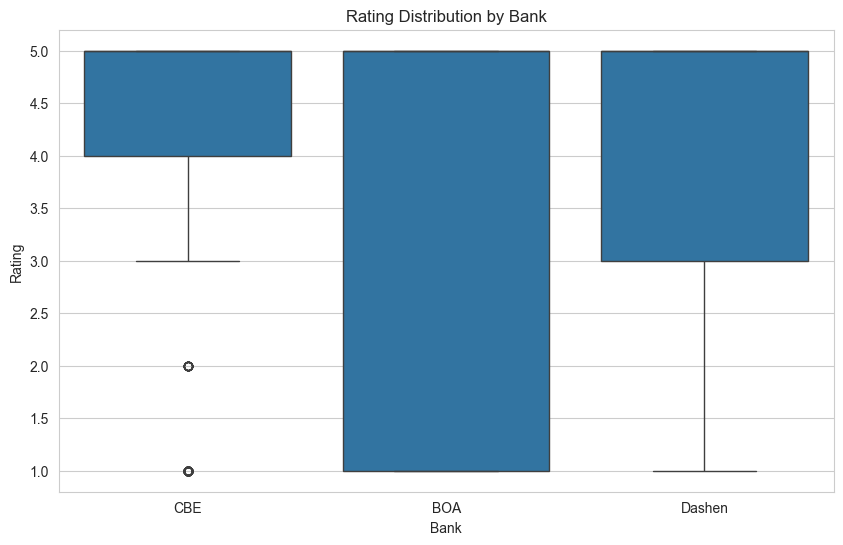

In [4]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='bank',
    y='rating'
)

plt.title("Rating Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Rating")

plt.show()

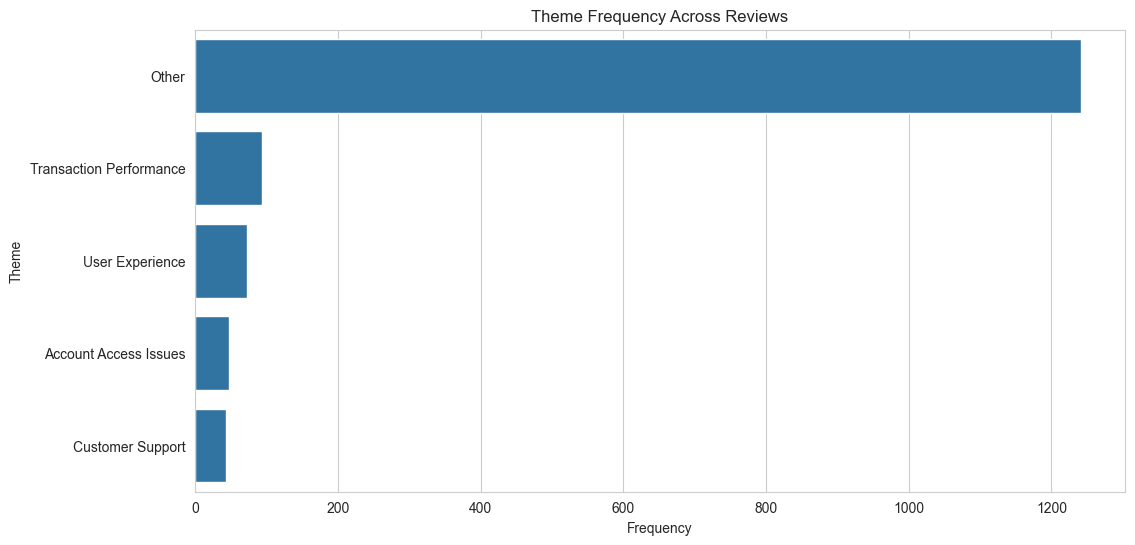

In [5]:
plt.figure(figsize=(12,6))

theme_counts = df['identified_theme'].value_counts()

sns.barplot(
    x=theme_counts.values,
    y=theme_counts.index
)

plt.title("Theme Frequency Across Reviews")
plt.xlabel("Frequency")
plt.ylabel("Theme")

plt.show()

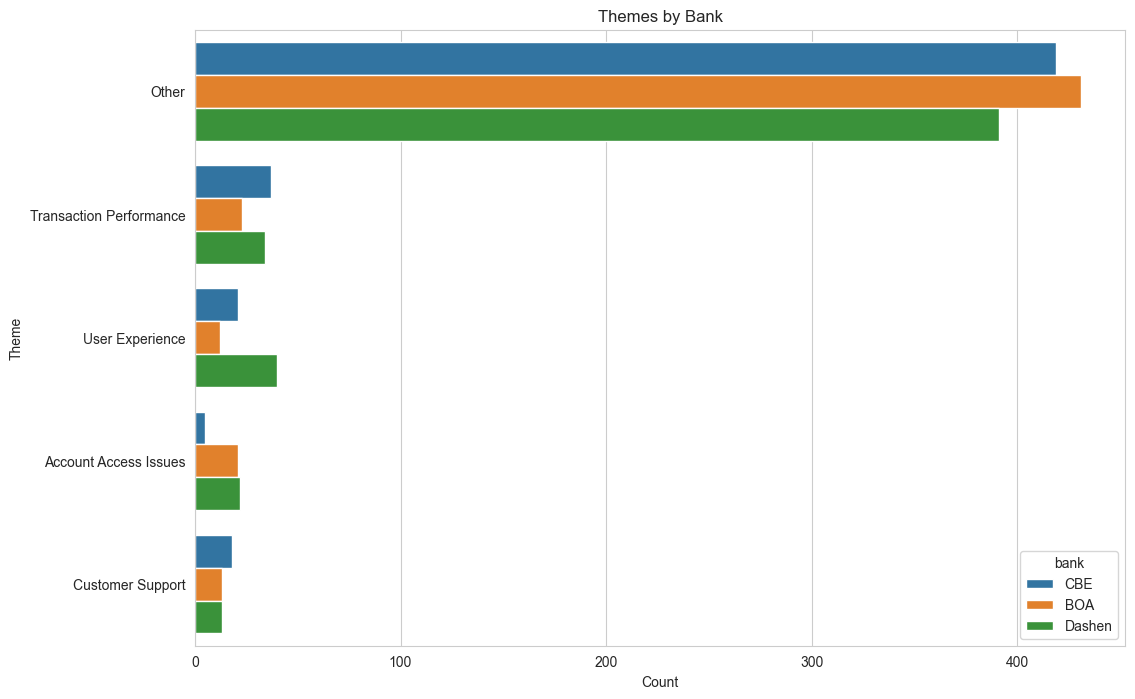

In [6]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    y='identified_theme',
    hue='bank',
    order=df['identified_theme'].value_counts().index
)

plt.title("Themes by Bank")
plt.xlabel("Count")
plt.ylabel("Theme")

plt.show()

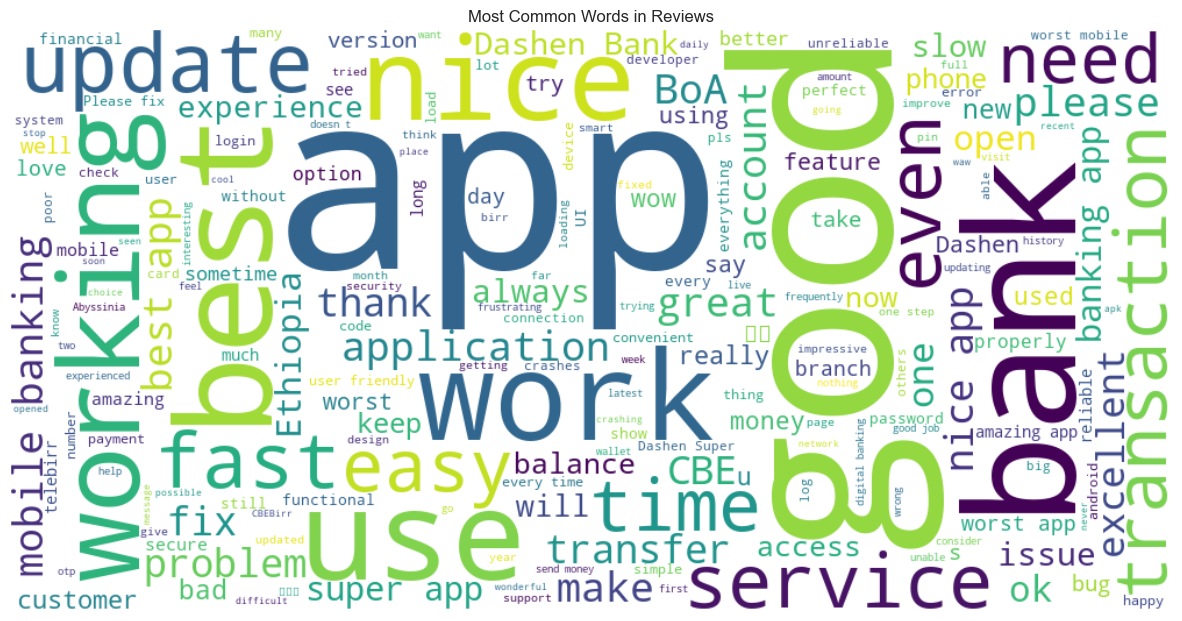

In [7]:
from wordcloud import WordCloud

text = " ".join(df['review'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Most Common Words in Reviews")

plt.show()

In [8]:
avg_rating = df.groupby('bank')['rating'].mean()

print(avg_rating)

bank
BOA       3.566
CBE       4.122
Dashen    3.936
Name: rating, dtype: float64


In [9]:
sentiment_summary = pd.crosstab(
    df['bank'],
    df['sentiment_label'],
    normalize='index'
) * 100

print(sentiment_summary.round(2))

sentiment_label  negative  neutral  positive
bank                                        
BOA                  17.4     31.2      51.4
CBE                  10.4     22.8      66.8
Dashen               12.6     23.4      64.0


In [10]:
negative_reviews = df[
    df['sentiment_label'] == 'negative'
]

negative_reviews[['bank', 'review']].head(20)

,bank,review
2,CBE,worst
24,CBE,Very Secure but very poor interface and limite...
34,CBE,why is my transaction fee hidden? Why doesn't ...
40,CBE,There is a a problem when updating the app
52,CBE,The app is getting worse and worse after every...
59,CBE,features በጣም ወድጄዋለሁ ነገር ግን አንድ ችግር አይቼዋለሁ ።APP...
63,CBE,This app has never been efficient at all
75,CBE,fixed problem
94,CBE,it's no functional problem
116,CBE,worst apk for a big bank


In [11]:
positive_reviews = df[
    df['sentiment_label'] == 'positive'
]

positive_reviews[['bank', 'review']].head(20)

,bank,review
0,CBE,Good
4,CBE,good apps
5,CBE,ok
6,CBE,this update got crazy i don't know what's goin...
7,CBE,thanks for you 😘
8,CBE,it's okay
11,CBE,wow
12,CBE,nice app
14,CBE,best app for financial activities 🙌
17,CBE,best app for financial sector


In [12]:
plt.savefig(
    "../reports/sentiment_distribution.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [13]:
print(df.shape)

(1500, 8)


In [14]:
print(df['bank'].value_counts())

bank
CBE       500
BOA       500
Dashen    500
Name: count, dtype: int64


In [15]:
negative_reviews = df[
    df['sentiment_label'] == 'negative'
]

negative_reviews['review'].head(20)

2                                                  worst
24     Very Secure but very poor interface and limite...
34     why is my transaction fee hidden? Why doesn't ...
40            There is a a problem when updating the app
52     The app is getting worse and worse after every...
59     features በጣም ወድጄዋለሁ ነገር ግን አንድ ችግር አይቼዋለሁ ።APP...
63              This app has never been efficient at all
75                                         fixed problem
94                            it's no functional problem
116                             worst apk for a big bank
118    The app forcefully made me an update, since th...
131               unable to use it is not performed well
161    What's wrong after i update the app unable to ...
164                               not sure at the moment
173      I like it but sometimes there is a system error
176    This application was not that great, and its p...
190    I hope this bank have excellent Mobile app but...
197    there should be atm vouc

In [16]:
positive_reviews = df[
    df['sentiment_label'] == 'positive'
]

positive_reviews['review'].head(20)

0                                                  Good
4                                             good apps
5                                                    ok
6     this update got crazy i don't know what's goin...
7                                      thanks for you 😘
8                                             it's okay
11                                                  wow
12                                             nice app
14                  best app for financial activities 🙌
17                        best app for financial sector
18                              it's a good application
19                                        thank you cbe
20                                              is good
21                                                  wow
22                                     Good application
23    Nice, but I can't get some recently transactio...
25                                       very nice 100%
26                                              

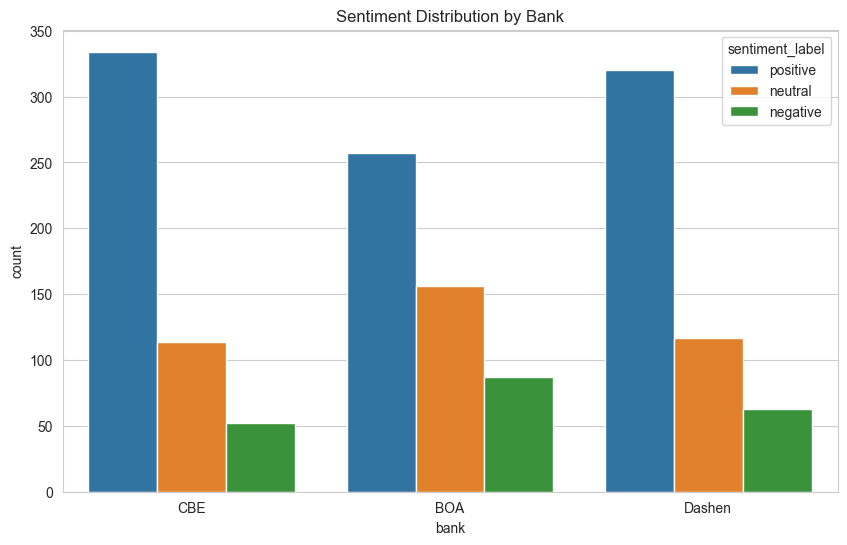

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='bank',
    hue='sentiment_label'
)

plt.title("Sentiment Distribution by Bank")

plt.show()

In [18]:
print(df['identified_theme'].value_counts())

identified_theme
Other                      1241
Transaction Performance      94
User Experience              73
Account Access Issues        48
Customer Support             44
Name: count, dtype: int64


In [19]:
df['date'] = pd.to_datetime(df['date'])

In [20]:
df['month'] = df['date'].dt.to_period('M')

In [21]:
sentiment_map = {
    'positive': 1,
    'neutral': 0,
    'negative': -1
}

df['sentiment_numeric'] = df['sentiment_label'].map(sentiment_map)

In [22]:
monthly_sentiment = df.groupby(
    ['month', 'bank']
)['sentiment_numeric'].mean().reset_index()

In [23]:
monthly_sentiment['month'] = monthly_sentiment['month'].astype(str)

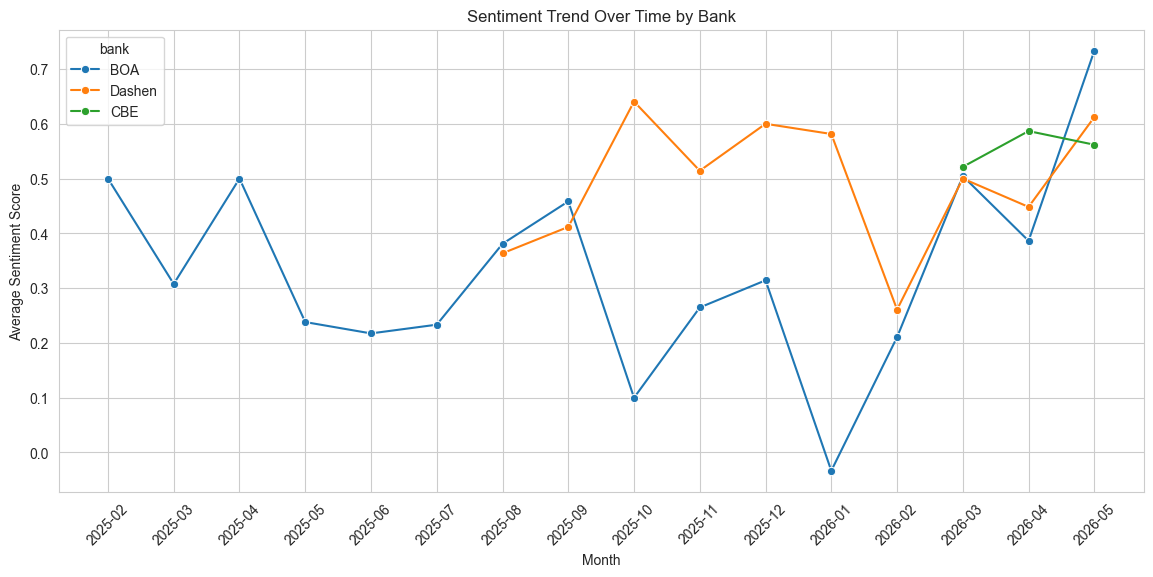

In [24]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sentiment,
    x='month',
    y='sentiment_numeric',
    hue='bank',
    marker='o'
)

plt.title("Sentiment Trend Over Time by Bank")

plt.xlabel("Month")

plt.ylabel("Average Sentiment Score")

plt.xticks(rotation=45)

plt.show()